In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/grove_data.csv')

# strip columns we don't really care about
df = df.drop(columns=["File number","AGCY_ST_CDE","AGCY_CTY_NM","Region","SUBMSN_DT", "OrgNAICS"])
df = df.dropna()
# Remove Freelance agents from dataset
df = df[df['AGCY_NBR'] != 994]
df

,AGCY_NBR,Agency Type,Producer ID,Policy effective date,Quoted Premium,Written Premium,PROD_NM,TOT_WW_EMPL_NBR,Status,Coverage Combination,Final Criteria
0,2219,Wholesaler,1,2024-11-19,3337,0,Trellis - 0323,60.0,Lost,EPL,Not Eligible
1,4411,Wholesaler,2,2025-10-09,8329,0,MPS Trellis,80.0,Quoted,EPL,Not Eligible
2,4411,Wholesaler,2,2025-10-09,9219,0,MPS Trellis,85.0,Quoted,EPL,Not Eligible
3,2896,Wholesaler,3,2025-11-14,722,0,Trellis - 0323,6.0,Quoted,EPL,Not Eligible
5,1415,Wholesaler,5,2026-05-03,3730,0,MPS Trellis,12.0,Quoted,EPL,Not Eligible
...,...,...,...,...,...,...,...,...,...,...,...
130957,1529,Retailer,5711,2025-08-01,650,650,Trellis - 0323,3.0,Issued,MPL,Eligible Enrolled
130958,3088,Retailer,2841,2025-07-10,5521,0,Trellis - 0323,27.0,Indicated,"D&O,Cyber,MPL",Eligible Enrolled
130959,1729,Retailer,5828,2025-08-29,3074,0,MPS Trellis,1.0,Declined,MPL,Not Eligible
130960,2456,Retailer,2976,2026-01-06,723,0,Trellis - 0323,1.0,Quoted,MPL,Eligible Enrolled


In [ ]:
df["Status"].value_counts()
old_df = df.copy()

Promotions:

2x Points: 2025-01-01 00:00:00 to 2025-01-31 00:00:00

2x Points for > $5k business: 2025-02-01 00:00:00 to 2025-03-15 00:00:00

2x Points: 2025-07-01 00:00:00 to 2025-07-31 00:00:00

2x Points: 2026-01-01 00:00:00 to 2026-01-31 00:00:00

In [ ]:
df['Policy effective date'] = pd.to_datetime(df['Policy effective date'])

is_during_promotion = (
    (df['Policy effective date'] >= '2025-01-01 00:00:00') & (df['Policy effective date'] <= '2025-01-31 00:00:00') |
    (df['Policy effective date'] >= '2025-02-01 00:00:00') & (df['Policy effective date'] <= '2025-03-15 00:00:00') |
    (df['Policy effective date'] >= '2025-07-01 00:00:00') & (df['Policy effective date'] <= '2025-07-31 00:00:00') |
    (df['Policy effective date'] >= '2026-01-01 00:00:00') & (df['Policy effective date'] <= '2026-01-31 00:00:00')
)

df['Promotion'] = is_during_promotion
df

,AGCY_NBR,Agency Type,Producer ID,Policy effective date,Quoted Premium,Written Premium,PROD_NM,TOT_WW_EMPL_NBR,Status,Coverage Combination,Final Criteria,Promotion
0,2219,Wholesaler,1,2024-11-19,3337,0,Trellis - 0323,60.0,Lost,EPL,Not Eligible,False
1,4411,Wholesaler,2,2025-10-09,8329,0,MPS Trellis,80.0,Quoted,EPL,Not Eligible,False
2,4411,Wholesaler,2,2025-10-09,9219,0,MPS Trellis,85.0,Quoted,EPL,Not Eligible,False
3,2896,Wholesaler,3,2025-11-14,722,0,Trellis - 0323,6.0,Quoted,EPL,Not Eligible,False
5,1415,Wholesaler,5,2026-05-03,3730,0,MPS Trellis,12.0,Quoted,EPL,Not Eligible,False
...,...,...,...,...,...,...,...,...,...,...,...,...
130957,1529,Retailer,5711,2025-08-01,650,650,Trellis - 0323,3.0,Issued,MPL,Eligible Enrolled,False
130958,3088,Retailer,2841,2025-07-10,5521,0,Trellis - 0323,27.0,Indicated,"D&O,Cyber,MPL",Eligible Enrolled,True
130959,1729,Retailer,5828,2025-08-29,3074,0,MPS Trellis,1.0,Declined,MPL,Not Eligible,False
130960,2456,Retailer,2976,2026-01-06,723,0,Trellis - 0323,1.0,Quoted,MPL,Eligible Enrolled,True


In [ ]:
df['conversion_target'] = df['Status'].apply(lambda x: 1 if x == 'Issued' else (0 if x == 'Quoted' else np.nan))
df = df.dropna(subset=['conversion_target']).copy()

In [ ]:
df['POLICY_MONTH'] = df['Policy effective date'].dt.to_period('M')

In [ ]:
issued_quoted_df = df[df['Status'].isin(['Issued', 'Quoted'])]

quote_ratio = issued_quoted_df.groupby('Promotion').apply(lambda x:
    (x['Status'] == 'Issued').sum() / len(x)
)

print("Quote Ratio by Promotion:")
print(quote_ratio)

Quote Ratio by Promotion:
Promotion
False    0.377434
True     0.370542
dtype: float64


/tmp/ipykernel_21146/2156324425.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  quote_ratio = issued_quoted_df.groupby('Promotion').apply(lambda x:


In [ ]:
df

,AGCY_NBR,Agency Type,Producer ID,Policy effective date,Quoted Premium,Written Premium,PROD_NM,TOT_WW_EMPL_NBR,Status,Coverage Combination,Final Criteria,Promotion,conversion_target,POLICY_MONTH
1,4411,Wholesaler,2,2025-10-09,8329,0,MPS Trellis,80.0,Quoted,EPL,Not Eligible,False,0.0,2025-10
2,4411,Wholesaler,2,2025-10-09,9219,0,MPS Trellis,85.0,Quoted,EPL,Not Eligible,False,0.0,2025-10
3,2896,Wholesaler,3,2025-11-14,722,0,Trellis - 0323,6.0,Quoted,EPL,Not Eligible,False,0.0,2025-11
5,1415,Wholesaler,5,2026-05-03,3730,0,MPS Trellis,12.0,Quoted,EPL,Not Eligible,False,0.0,2026-05
9,1616,Wholesaler,8,2026-03-26,3222,0,Trellis - 0323,22.0,Quoted,EPL,Not Eligible,False,0.0,2026-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
130955,2509,Retailer,10108,2025-10-23,3824,0,Trellis - 0323,3.0,Quoted,"Cyber,MPL",Eligible Not Enrolled,False,0.0,2025-10
130956,2816,Retailer,7349,2025-10-10,1232,1232,Trellis - 0323,1.0,Issued,MPL,Eligible Not Enrolled,False,1.0,2025-10
130957,1529,Retailer,5711,2025-08-01,650,650,Trellis - 0323,3.0,Issued,MPL,Eligible Enrolled,False,1.0,2025-08
130960,2456,Retailer,2976,2026-01-06,723,0,Trellis - 0323,1.0,Quoted,MPL,Eligible Enrolled,True,0.0,2026-01


### Exploratory Data Analysis: Focusing on 'Status' Column

In [ ]:
# Distribution of Status column
print("Distribution of 'Status' column:")
print(df['Status'].value_counts())
print("\nPercentage distribution of 'Status' column:")
print(df['Status'].value_counts(normalize=True) * 100)


Distribution of 'Status' column:
Status
Quoted    35273
Issued    21282
Name: count, dtype: int64

Percentage distribution of 'Status' column:
Status
Quoted    62.369375
Issued    37.630625
Name: proportion, dtype: float64


#### Relationship between 'Status' and other Categorical Features

#### Analyze Conversion Rate (`conversion_target`) by Categorical Features

/tmp/ipykernel_21146/2120252731.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=conversion_rates.index, y=conversion_rates.values, palette='coolwarm')


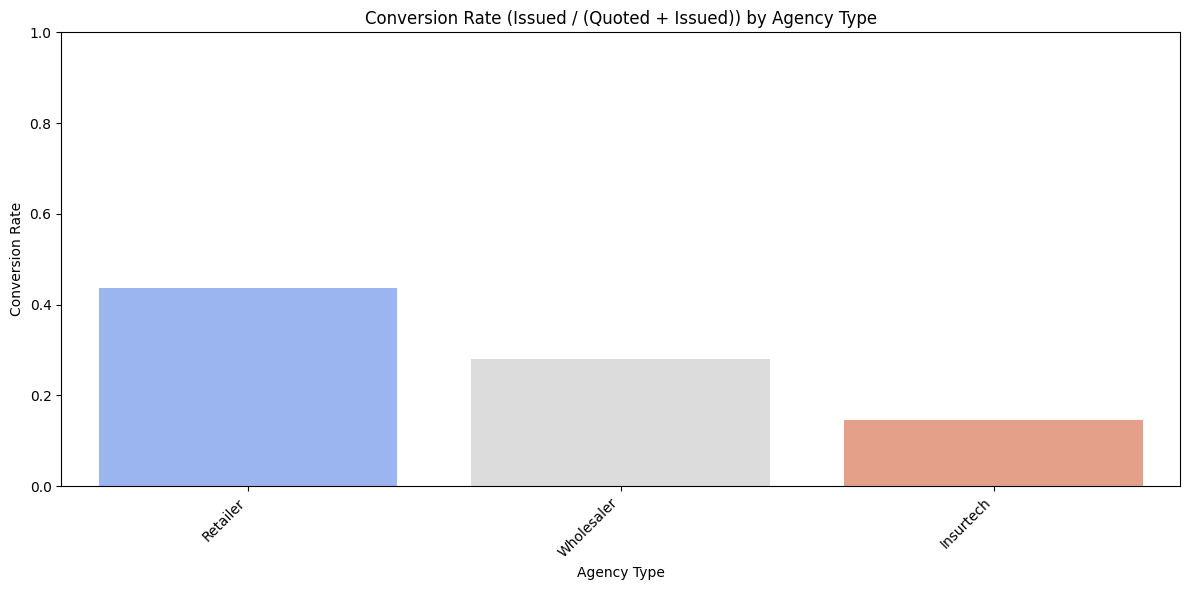

/tmp/ipykernel_21146/2120252731.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=conversion_rates.index, y=conversion_rates.values, palette='coolwarm')


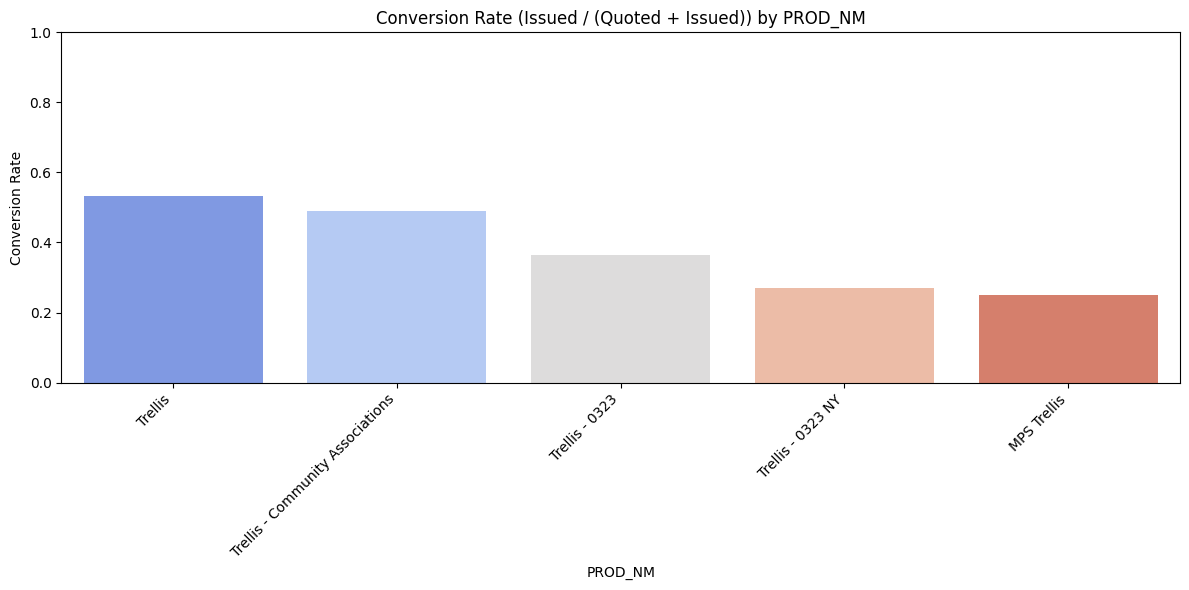

/tmp/ipykernel_21146/2120252731.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=conversion_rates.index, y=conversion_rates.values, palette='coolwarm')


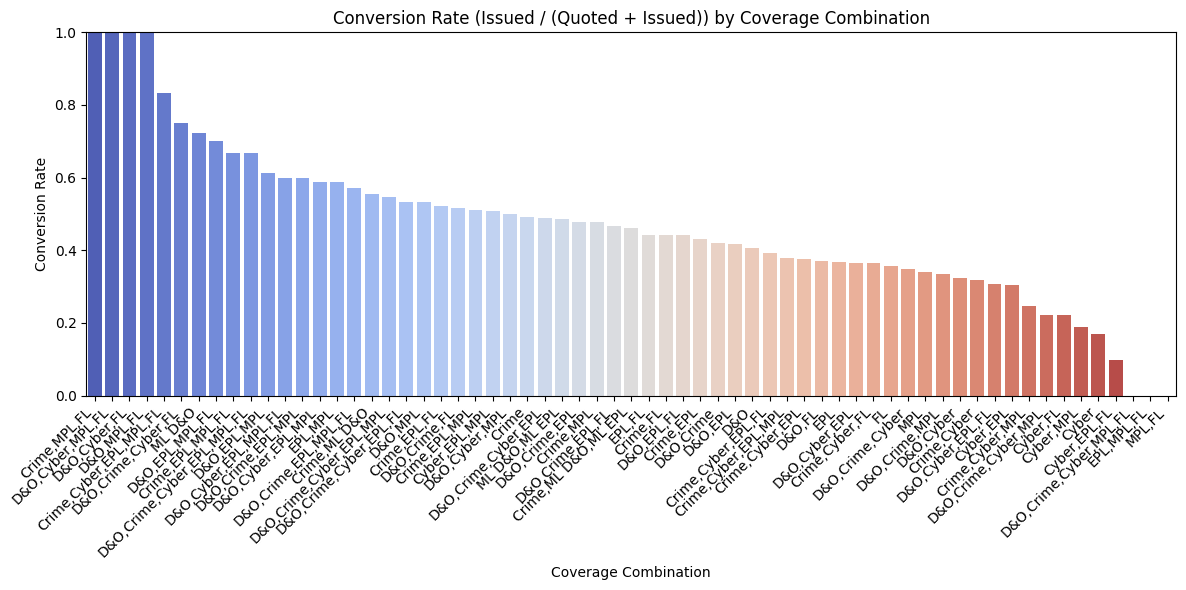

/tmp/ipykernel_21146/2120252731.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=conversion_rates.index, y=conversion_rates.values, palette='coolwarm')


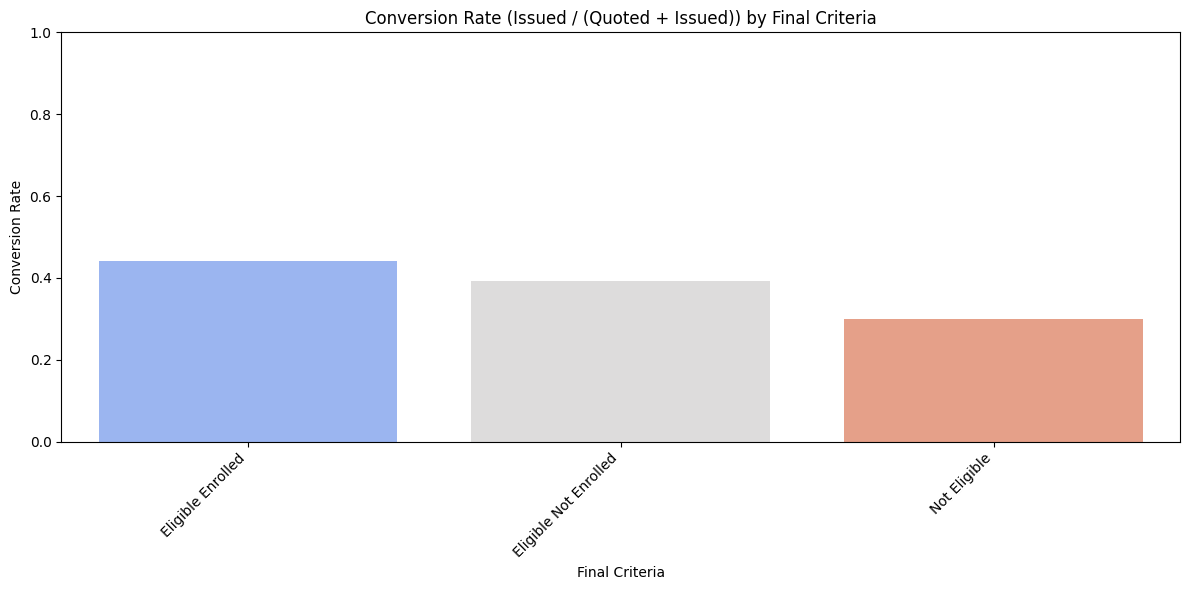

/tmp/ipykernel_21146/2120252731.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=conversion_rates.index, y=conversion_rates.values, palette='coolwarm')


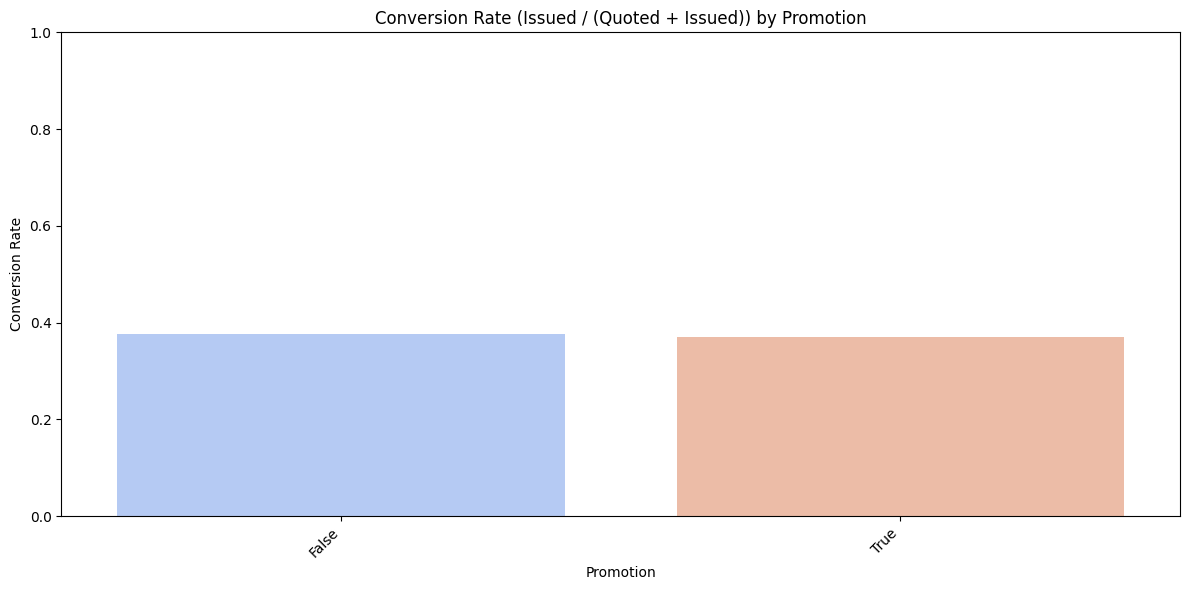

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

categorical_cols_for_conversion = ['Agency Type', 'PROD_NM', 'Coverage Combination', 'Final Criteria', 'Promotion']

for col in categorical_cols_for_conversion:

    conversion_rates = df.groupby(col)['conversion_target'].mean().dropna().sort_values(ascending=False)

    plt.figure(figsize=(12, 6))
    sns.barplot(x=conversion_rates.index, y=conversion_rates.values, palette='coolwarm')
    plt.title(f'Conversion Rate (Issued / (Quoted + Issued)) by {col}')
    plt.xlabel(col)
    plt.ylabel('Conversion Rate')
    plt.xticks(rotation=45, ha='right')
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()

#### Conversion Rate by Categorical Features, Split by Promotion Status

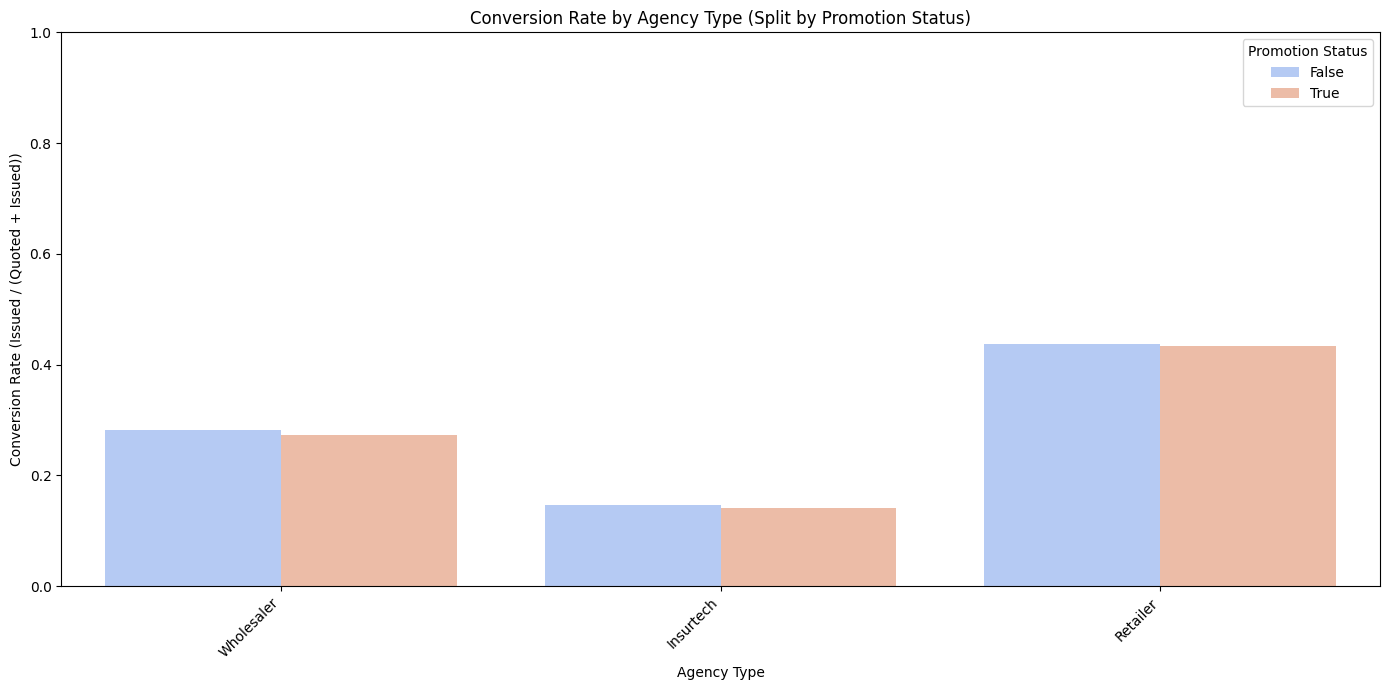

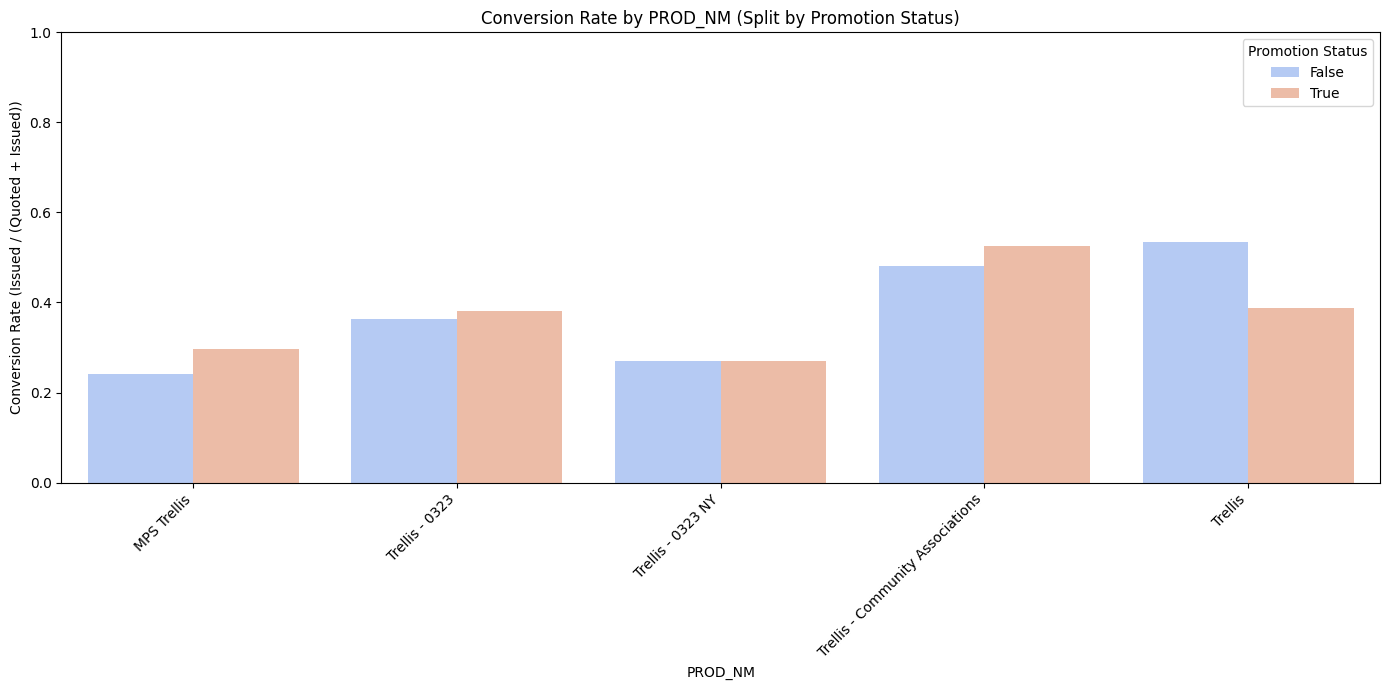

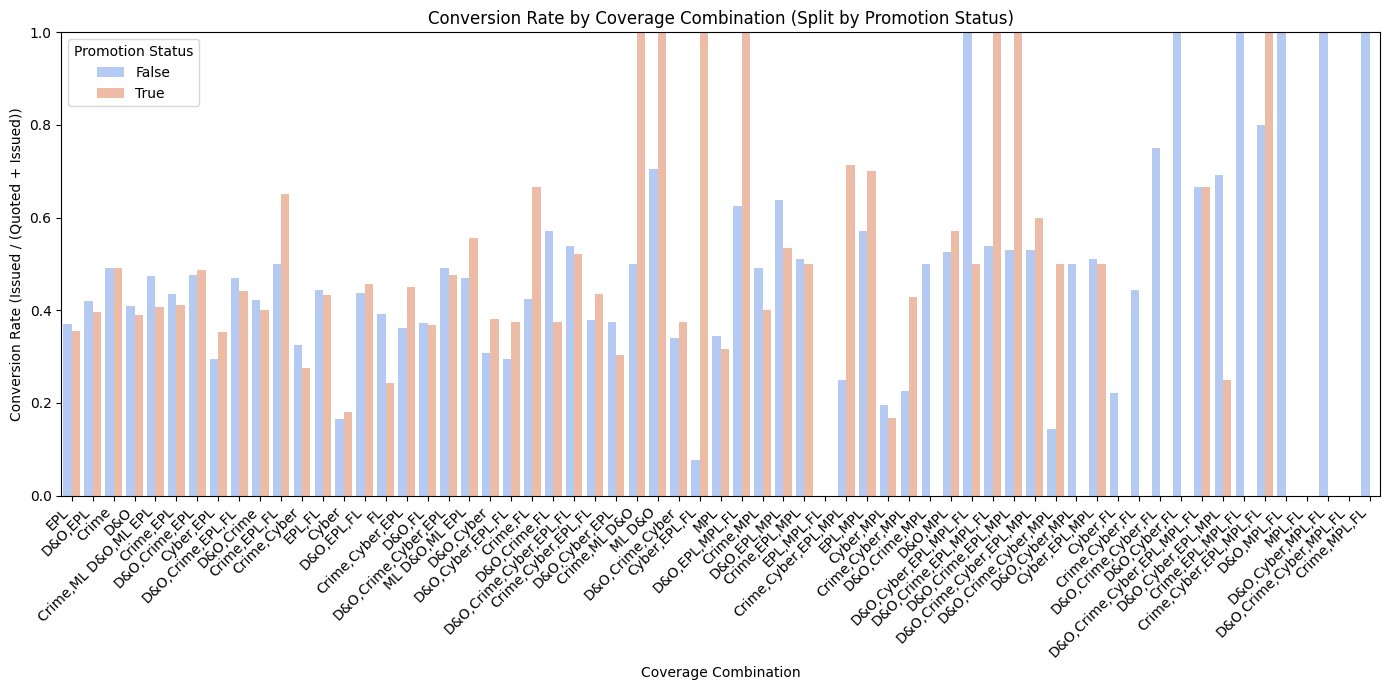

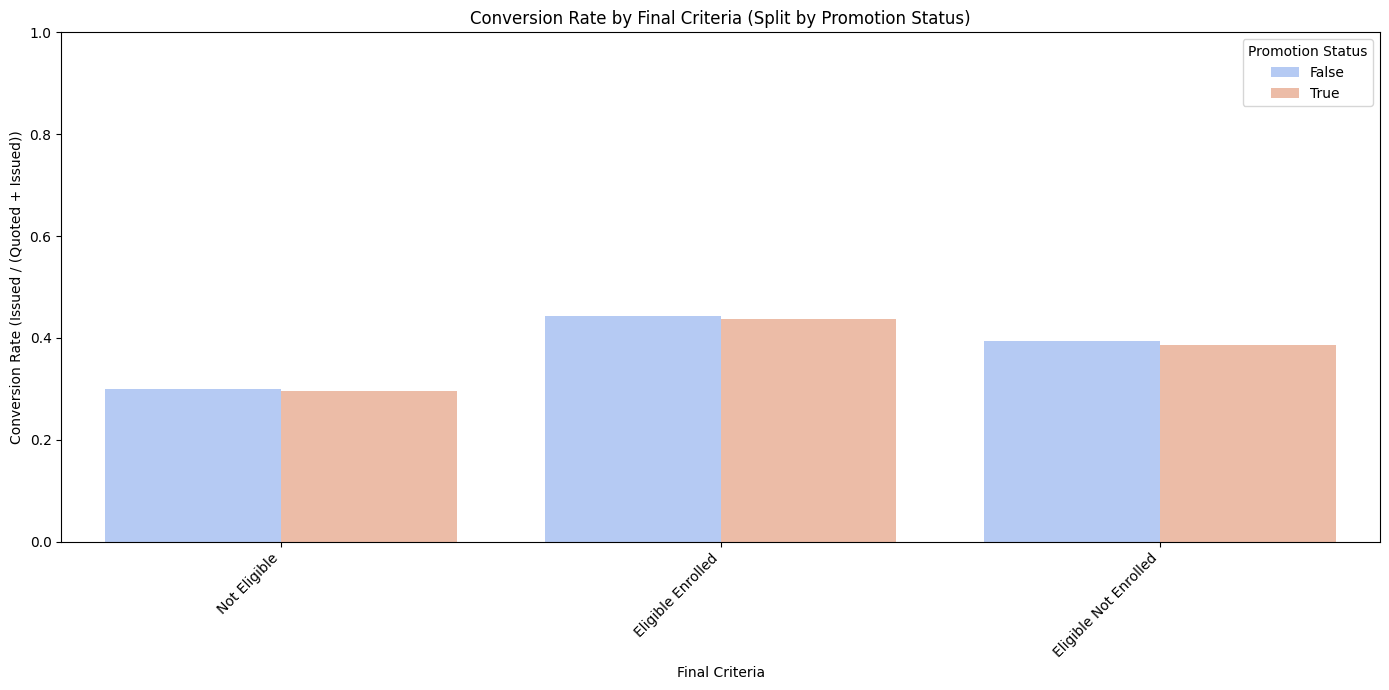

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

categorical_cols_for_detailed_analysis = ['Agency Type', 'PROD_NM', 'Coverage Combination', 'Final Criteria']

for col in categorical_cols_for_detailed_analysis:
    plt.figure(figsize=(14, 7))
    # Conversion rate and plot
    sns.barplot(data=df, x=col, y='conversion_target', hue='Promotion', palette='coolwarm', errorbar=None)
    plt.title(f'Conversion Rate by {col} (Split by Promotion Status)')
    plt.xlabel(col)
    plt.ylabel('Conversion Rate (Issued / (Quoted + Issued))')
    plt.xticks(rotation=45, ha='right')
    plt.ylim(0, 1)
    plt.legend(title='Promotion Status')
    plt.tight_layout()
    plt.show()

#### Analyzing Conversion Rate by Quoted Premium during Promotions

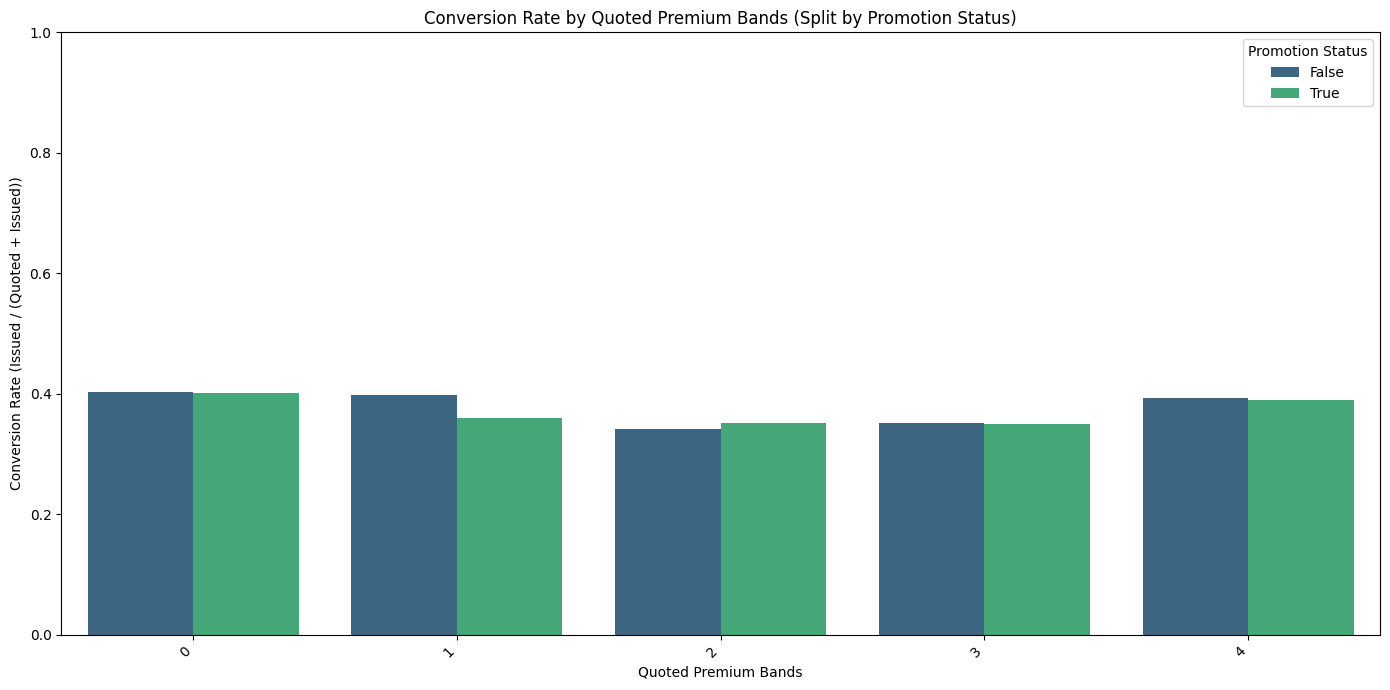

In [ ]:
# Quoted Premium
df['Premium_Bands'] = pd.qcut(df['Quoted Premium'], q=5, labels=False, duplicates='drop')

plt.figure(figsize=(14, 7))
sns.barplot(data=df, x='Premium_Bands', y='conversion_target', hue='Promotion', palette='viridis', errorbar=None)
plt.title('Conversion Rate by Quoted Premium Bands (Split by Promotion Status)')
plt.xlabel('Quoted Premium Bands')
plt.ylabel('Conversion Rate (Issued / (Quoted + Issued))')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1)
plt.legend(title='Promotion Status')
plt.tight_layout()
plt.show()

In [ ]:
df["Status"].value_counts()

,count
Status,
Quoted,35273
Issued,21282


#### Analyzing Average Premium (Deal Size) during Promotions


Average Quoted Premium (for Quoted or Issued policies) by Promotion Status:
Promotion
False    3696.285478
True     3755.263250
Name: Quoted Premium, dtype: float64

Average Written Premium (for Issued policies) by Promotion Status:
Promotion
False    4201.812531
True     4310.031277
Name: Written Premium, dtype: float64


/tmp/ipykernel_21146/1113375012.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_quoted_premium_by_promotion.index, y=avg_quoted_premium_by_promotion.values, palette='coolwarm', ax=axes[0])
/tmp/ipykernel_21146/1113375012.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_written_premium_by_promotion.index, y=avg_written_premium_by_promotion.values, palette='viridis', ax=axes[1])


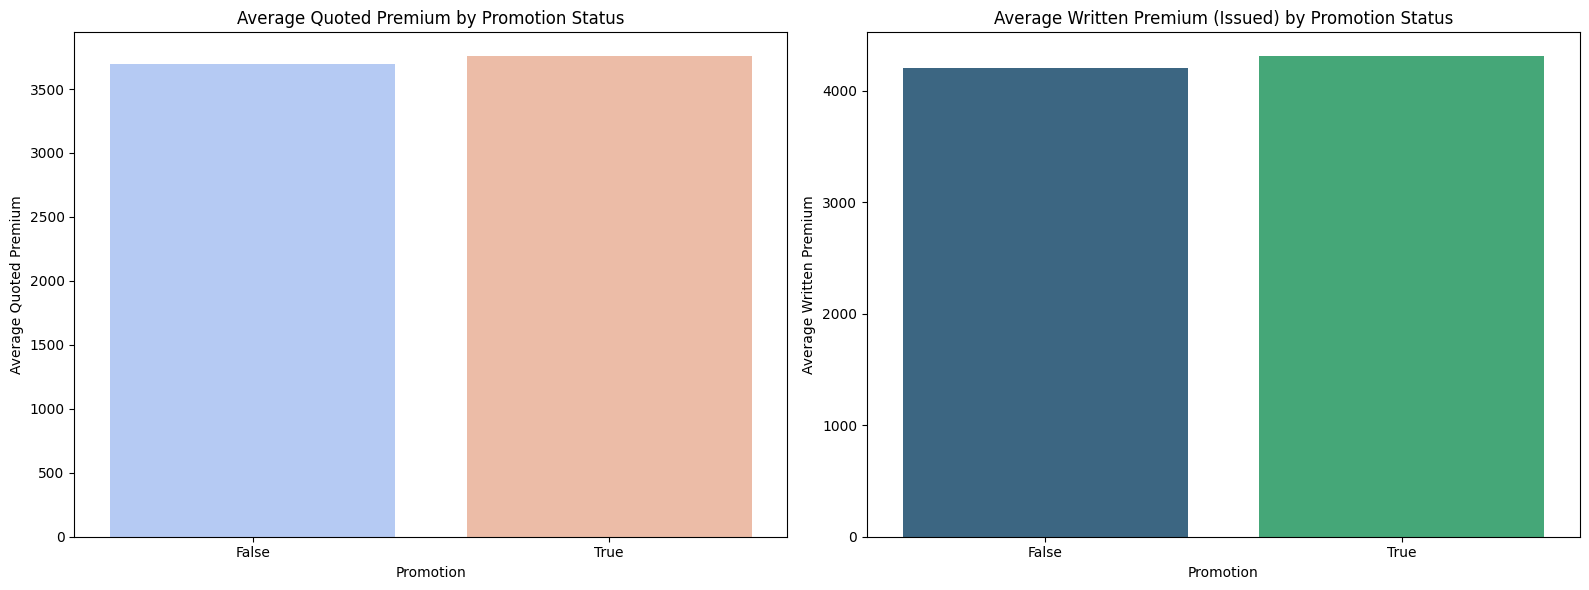

In [ ]:
# Filter for 'Quoted' or 'Issued' statuses, as these are relevant for premium analysis
premium_df = df[df['Status'].isin(['Quoted', 'Issued', "Lost", "Declined"])].copy()

# Calculate average Quoted Premium for Quoted/Issued policies, by Promotion status
avg_quoted_premium_by_promotion = premium_df.groupby('Promotion')['Quoted Premium'].mean()
print("\nAverage Quoted Premium (for Quoted or Issued policies) by Promotion Status:")
print(avg_quoted_premium_by_promotion)

# Calculate average Written Premium for Issued policies, by Promotion status
avg_written_premium_by_promotion = premium_df[premium_df['Status'] == 'Issued'].groupby('Promotion')['Written Premium'].mean()
print("\nAverage Written Premium (for Issued policies) by Promotion Status:")
print(avg_written_premium_by_promotion)

# Visualize these averages
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(x=avg_quoted_premium_by_promotion.index, y=avg_quoted_premium_by_promotion.values, palette='coolwarm', ax=axes[0])
axes[0].set_title('Average Quoted Premium by Promotion Status')
axes[0].set_xlabel('Promotion')
axes[0].set_ylabel('Average Quoted Premium')
axes[0].ticklabel_format(style='plain', axis='y')

sns.barplot(x=avg_written_premium_by_promotion.index, y=avg_written_premium_by_promotion.values, palette='viridis', ax=axes[1])
axes[1].set_title('Average Written Premium (Issued) by Promotion Status')
axes[1].set_xlabel('Promotion')
axes[1].set_ylabel('Average Written Premium')
axes[1].ticklabel_format(style='plain', axis='y')

plt.tight_layout()
plt.show()

#### Analyzing Conversion Rate Trends Over Time, Split by Promotion Status

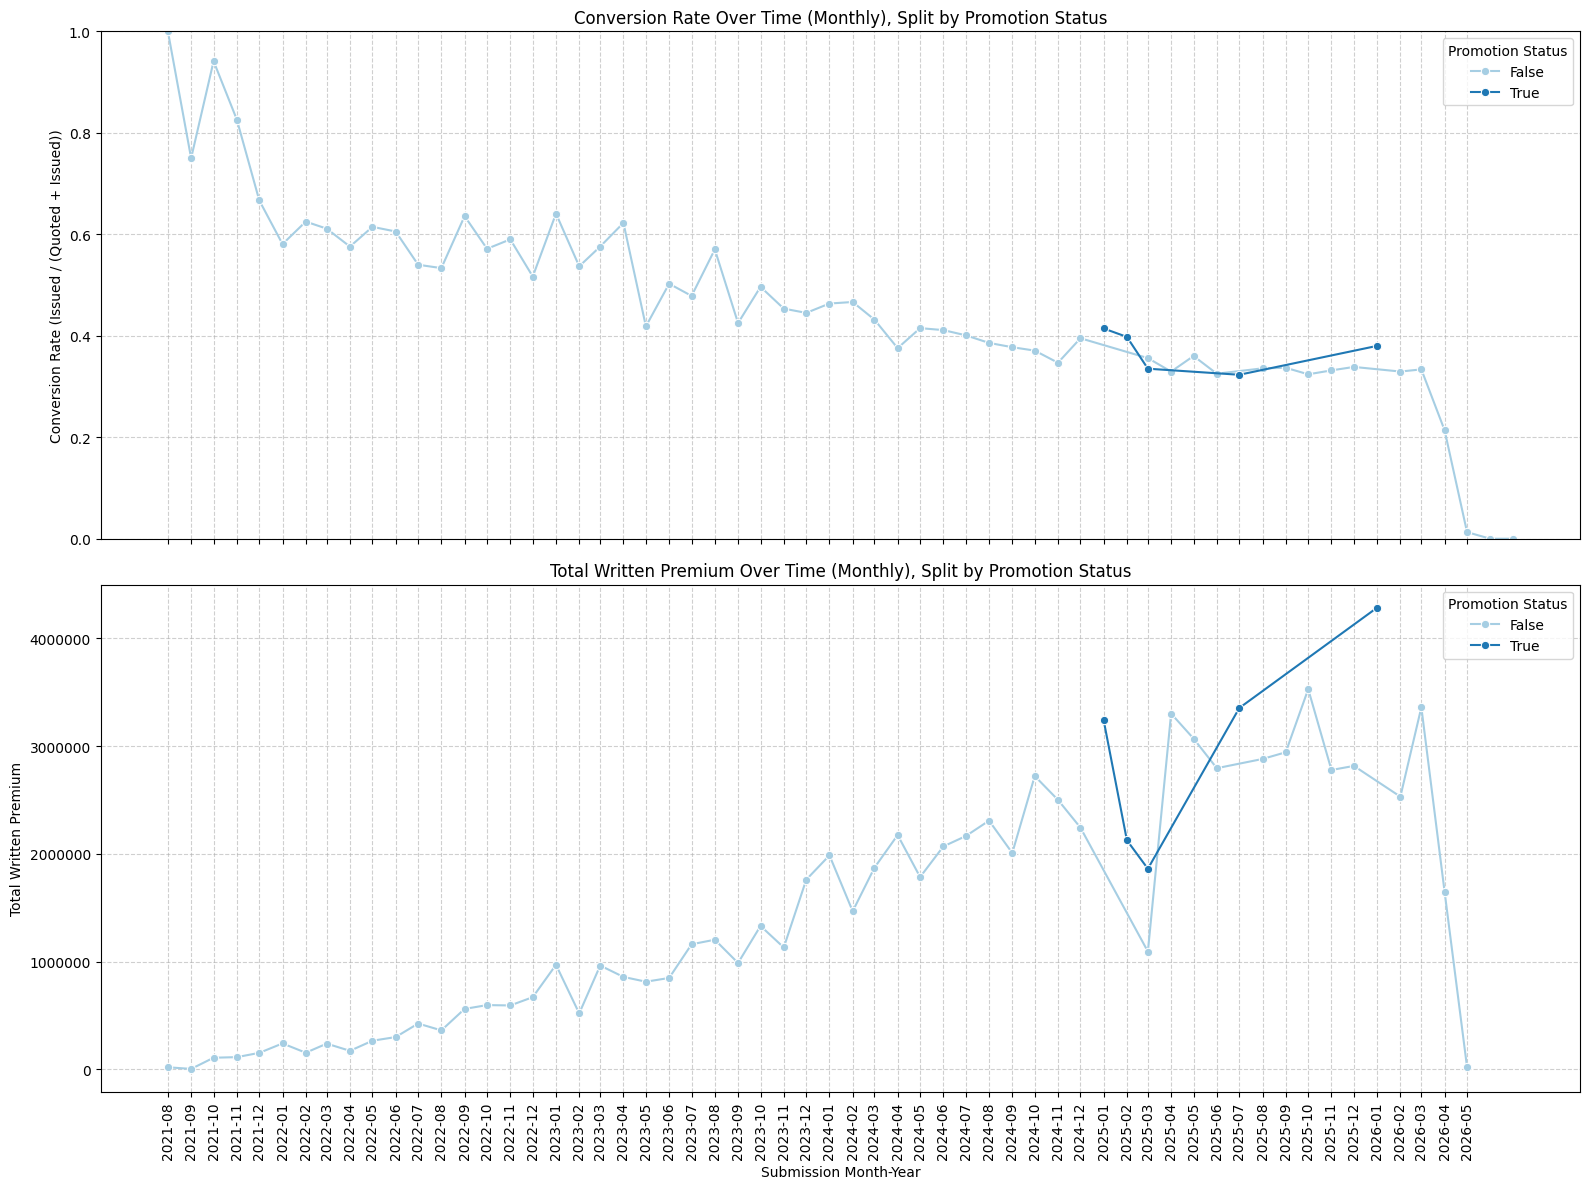

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate monthly conversion rate
monthly_conversion_rate = df.groupby(['POLICY_MONTH', 'Promotion'])['conversion_target'].mean().reset_index()

# Calculate monthly total written premium for issued policies
monthly_written_premium = df[df['Status'] == 'Issued'].groupby(['POLICY_MONTH', 'Promotion'])['Written Premium'].sum().reset_index()

# Convert 'POLICY_MONTH' to datetime for proper plotting
monthly_conversion_rate['POLICY_MONTH'] = monthly_conversion_rate['POLICY_MONTH'].dt.to_timestamp()
monthly_written_premium['POLICY_MONTH'] = monthly_written_premium['POLICY_MONTH'].dt.to_timestamp()

fig, axes = plt.subplots(2, 1, figsize=(16, 12), sharex=True)

# Plot Conversion Rate Over Time
sns.lineplot(data=monthly_conversion_rate.sort_values('POLICY_MONTH'),
             x='POLICY_MONTH', y='conversion_target', hue='Promotion',
             marker='o', palette='Paired', ax=axes[0])
axes[0].set_title('Conversion Rate Over Time (Monthly), Split by Promotion Status')
axes[0].set_ylabel('Conversion Rate (Issued / (Quoted + Issued))')
axes[0].set_ylim(0, 1)
axes[0].legend(title='Promotion Status')
axes[0].grid(True, linestyle='--', alpha=0.6)

# Plot Total Written Premium Over Time
sns.lineplot(data=monthly_written_premium.sort_values('POLICY_MONTH'),
             x='POLICY_MONTH', y='Written Premium', hue='Promotion',
             marker='o', palette='Paired', ax=axes[1])
axes[1].set_title('Total Written Premium Over Time (Monthly), Split by Promotion Status')
axes[1].set_xlabel('Submission Month-Year')
axes[1].set_ylabel('Total Written Premium')
axes[1].ticklabel_format(style='plain', axis='y')
axes[1].legend(title='Promotion Status')
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].set_xticks(monthly_written_premium['POLICY_MONTH'].unique())
axes[1].set_xticklabels([x.strftime('%Y-%m') for x in monthly_written_premium['POLICY_MONTH'].unique()], rotation=90)

plt.tight_layout()
plt.show()

/tmp/ipykernel_21146/1089522011.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Promotion Status')


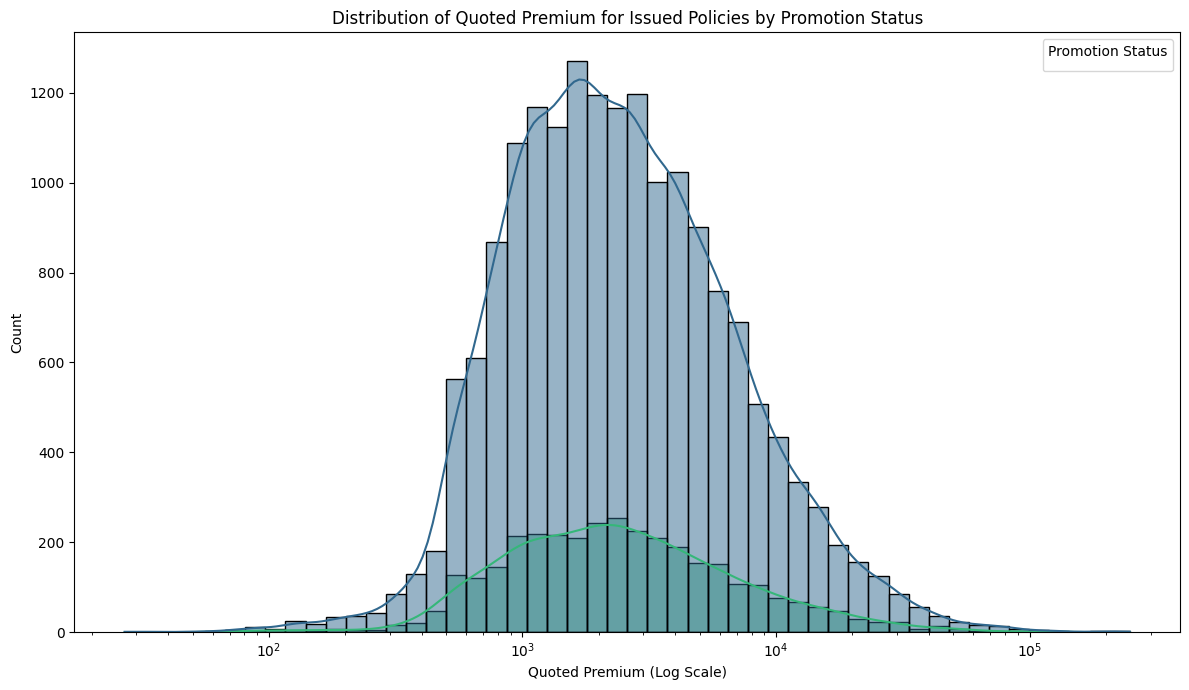

In [ ]:
# Checking distribution
issued_premium_df = df[(df['Status'] == 'Issued') & (df['Quoted Premium'] > 0)].copy()

if not issued_premium_df.empty:
    plt.figure(figsize=(12, 7))
    sns.histplot(data=issued_premium_df, x='Quoted Premium', hue='Promotion', kde=True,
                 palette='viridis', bins=50, log_scale=True)
    plt.title('Distribution of Quoted Premium for Issued Policies by Promotion Status')
    plt.xlabel('Quoted Premium (Log Scale)')
    plt.ylabel('Count')
    plt.legend(title='Promotion Status')
    plt.tight_layout()
    plt.show()
else:
    print("No issued policies with positive Quoted Premium found for this analysis.")

Do agents who use grove rewards stick?

Average Number of Issued/Quoted Policies per Agent (Producer ID) by Final Criteria:
          Final Criteria  Total_Issued_Quoted_Policies
0      Eligible Enrolled                      8.951039
1  Eligible Not Enrolled                      2.910376
2           Not Eligible                      8.550422


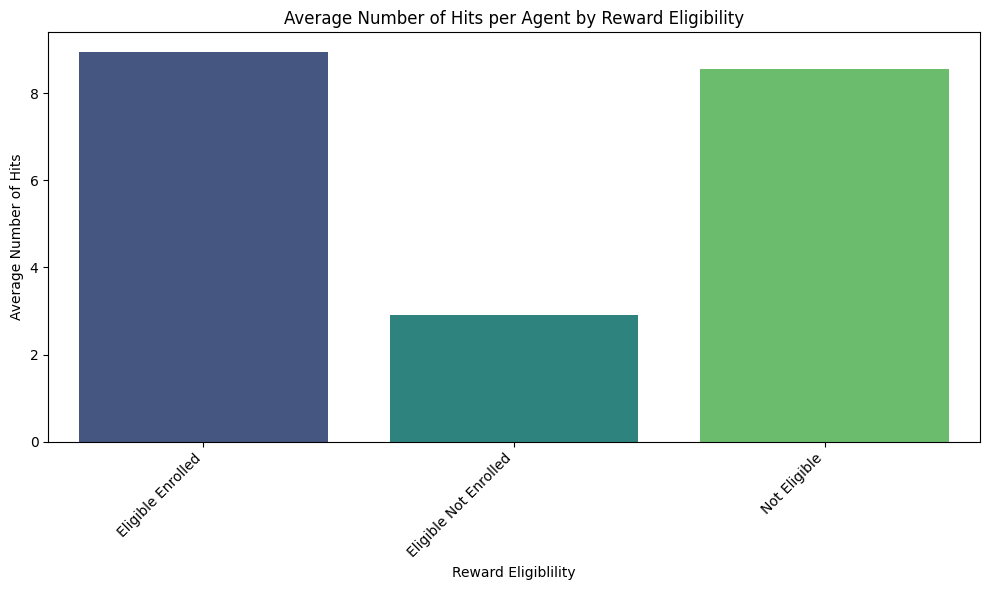


Number of Unique Agents (Producer ID) by Final Criteria:
          Final Criteria  Number_of_Unique_Agents
0      Eligible Enrolled                     2839
1  Eligible Not Enrolled                     2689
2           Not Eligible                     2727

Total Issued/Quoted Policies by Final Criteria:
          Final Criteria  Total_Policies_in_Criteria
0      Eligible Enrolled                       25412
1  Eligible Not Enrolled                        7826
2           Not Eligible                       23317


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group by 'Producer ID' and 'Final Criteria' to count the total number of issued/quoted policies
# for each producer in each eligibility group. Since df is already filtered for
# conversion_target (Issued or Quoted), every row represents an issue/quote activity.
prod_nm_activity_counts = df.groupby(['Producer ID', 'Final Criteria']).size().reset_index(name='Total_Issued_Quoted_Policies')

# Calculate the average number of issued/quoted policies per Producer ID for each Final Criteria group
avg_policies_per_prod_nm_by_criteria = prod_nm_activity_counts.groupby('Final Criteria')['Total_Issued_Quoted_Policies'].mean().reset_index()

print("Average Number of Issued/Quoted Policies per Agent (Producer ID) by Final Criteria:")
print(avg_policies_per_prod_nm_by_criteria)

# Visualize the comparison
plt.figure(figsize=(10, 6))
sns.barplot(x='Final Criteria', y='Total_Issued_Quoted_Policies', data=avg_policies_per_prod_nm_by_criteria, palette='viridis', hue='Final Criteria', legend=False)
plt.title('Average Number of Hits per Agent by Reward Eligibility')
plt.xlabel('Reward Eligiblility')
plt.ylabel('Average Number of Hits')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Additionally, provide the total number of unique agents and total policies in each criteria group for context
num_prod_nm_by_criteria = df.groupby('Final Criteria')['Producer ID'].nunique().reset_index(name='Number_of_Unique_Agents')
print("\nNumber of Unique Agents (Producer ID) by Final Criteria:")
print(num_prod_nm_by_criteria)

total_policies_by_criteria = df.groupby('Final Criteria').size().reset_index(name='Total_Policies_in_Criteria')
print("\nTotal Issued/Quoted Policies by Final Criteria:")
print(total_policies_by_criteria)

In [ ]:
df = old_df.copy()

Do agencies who use grove rewards (who are eligible and enrolled) stick around for multiple policies (# of rows with that agent’s ID)


Total Quotes and Issues by Final Criteria:
          Final Criteria  Total_Quotes_and_Issues
0      Eligible Enrolled                    36807
1  Eligible Not Enrolled                    12175
2           Not Eligible                    38088


/tmp/ipykernel_21146/4127908548.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Final Criteria', y='Quotes_and_Issues_Per_Agency', data=avg_quotes_issues_per_agency, palette='magma')


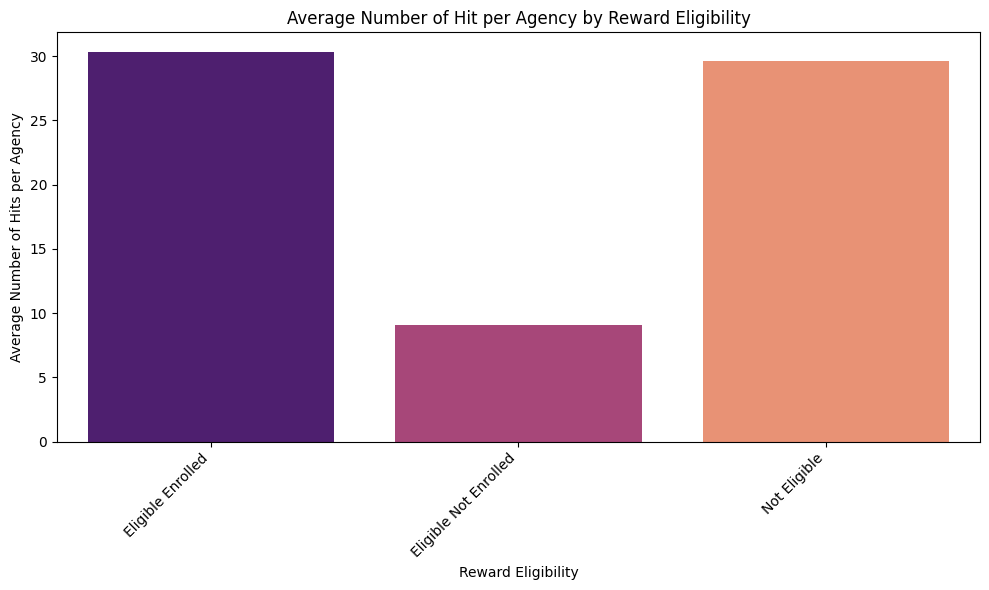

In [ ]:
# Calculate the total number of quotes and issues for each Final Criteria category
quotes_and_issues_by_criteria = df.groupby('Final Criteria').size().reset_index(name='Total_Quotes_and_Issues')

print("Total Quotes and Issues by Final Criteria:")
print(quotes_and_issues_by_criteria)

# Visualize the comparison
#plt.figure(figsize=(10, 6))
#sns.barplot(x='Final Criteria', y='Total_Quotes_and_Issues', data=quotes_and_issues_by_criteria, palette='viridis')
#plt.title('Total Number of Quotes and Issues by Eligibility')
#plt.xlabel('Final Criteria')
#plt.ylabel('Total Number of Quotes and Issues')
#plt.xticks(rotation=45, ha='right')
#plt.tight_layout()
#plt.show()

# Number of quotes/issues per agency within each group
agency_counts = df.groupby(['AGCY_NBR', 'Final Criteria']).size().reset_index(name='Quotes_and_Issues_Per_Agency')
avg_quotes_issues_per_agency = agency_counts.groupby('Final Criteria')['Quotes_and_Issues_Per_Agency'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='Final Criteria', y='Quotes_and_Issues_Per_Agency', data=avg_quotes_issues_per_agency, palette='magma')
plt.title('Average Number of Hit per Agency by Reward Eligibility')
plt.xlabel('Reward Eligibility')
plt.ylabel('Average Number of Hits per Agency')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Also do a group-by and compare the agency’s number of grove-enrolled numbers and the number of policies by the agency?

Agency Policy Comparison (Total vs. Enrolled):
   AGCY_NBR  Total Policies  Grove-Enrolled Policies  Percentage Enrolled
0         1              70                     60.0            85.714286
1         2              42                     37.0            88.095238
2         4               3                      0.0             0.000000
3         8              32                     30.0            93.750000
4         9              29                     20.0            68.965517


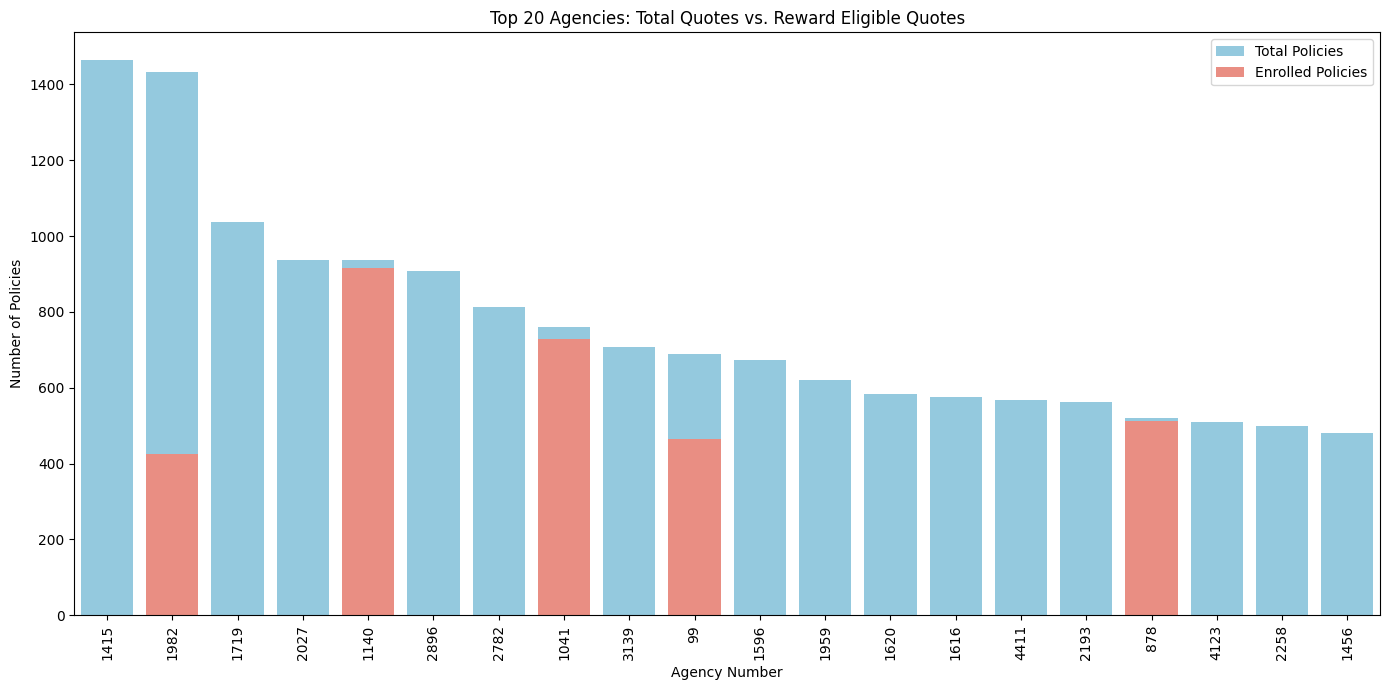

In [ ]:
# Calculate total policies per agency
total_policies_per_agency = df.groupby('AGCY_NBR').size().reset_index(name='Total Policies')

# Calculate enrolled policies per agency
grove_enrolled_policies_per_agency = df[df['Final Criteria'] == 'Eligible Enrolled'].groupby('AGCY_NBR').size().reset_index(name='Grove-Enrolled Policies')

# Merge the two dataframes
agency_policy_comparison = pd.merge(total_policies_per_agency,
                                    grove_enrolled_policies_per_agency,
                                    on='AGCY_NBR',
                                    how='left').fillna(0)

# Calculate the percentage of enrolled policies
agency_policy_comparison['Percentage Enrolled'] = (agency_policy_comparison['Grove-Enrolled Policies'] / agency_policy_comparison['Total Policies']) * 100

print("Agency Policy Comparison (Total vs. Enrolled):")
print(agency_policy_comparison.head())

# Visualize the comparison for a sample of agencies or overall distribution
plt.figure(figsize=(14, 7))

# Sort the data by 'Total Policies' for consistent plotting
sorted_agency_data = agency_policy_comparison.sort_values(by='Total Policies', ascending=False).head(20)

# Get the order of agency numbers based on total policies
agency_order = sorted_agency_data['AGCY_NBR'].tolist()

# Plot total policies
sns.barplot(x='AGCY_NBR', y='Total Policies', data=sorted_agency_data, color='skyblue', label='Total Policies', order=agency_order)

# Plot enrolled policies on top
sns.barplot(x='AGCY_NBR', y='Grove-Enrolled Policies', data=sorted_agency_data, color='salmon', label='Enrolled Policies', order=agency_order)

plt.title('Top 20 Agencies: Total Policies vs. Reward Eligible Policies')
plt.xlabel('Agency Number')
plt.ylabel('Number of Policies')
plt.xticks(rotation=90)
plt.legend()
plt.tight_layout()
plt.show()

### Conversion Rates by 'Final Criteria'


Conversion Rate by Final Criteria:
Final Criteria
Eligible Not Enrolled    0.393177
Eligible Enrolled        0.368635
Not Eligible             0.288789
Name: conversion_target, dtype: float64


/tmp/ipykernel_21146/440733105.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=conversion_rate_by_final_criteria.index, y=conversion_rate_by_final_criteria.values, palette='viridis')


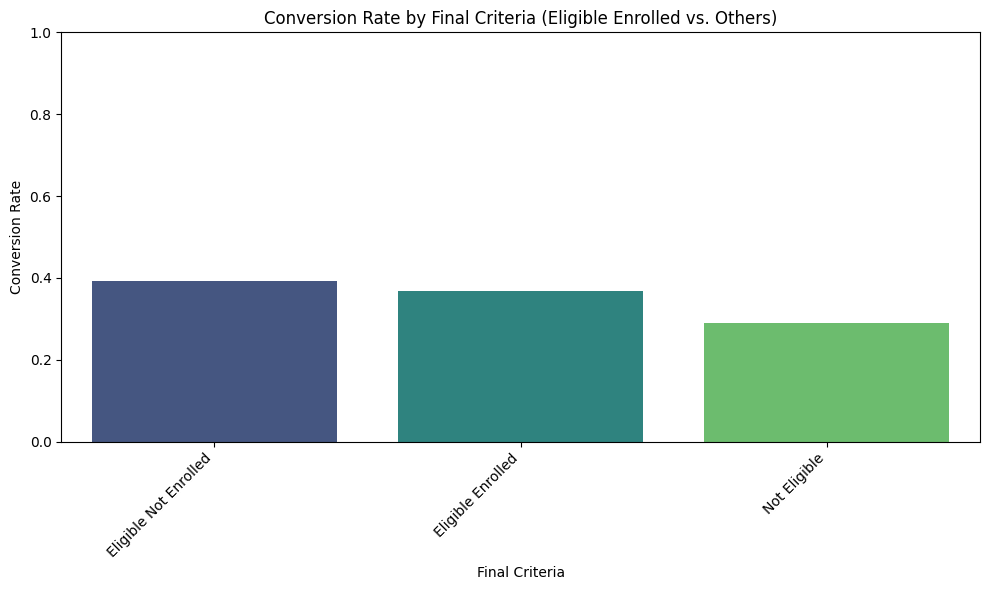

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Re-create df and apply transformations from previous cells
df = pd.read_csv('/content/grove_data.csv', encoding='latin1') # Using latin1 as discussed
df = df.drop(columns=["File number","AGCY_ST_CDE","AGCY_CTY_NM","Region","Producer ID", "OrgNAICS"]) # Ensure TOT_WW_EMPL_NBR is NOT dropped here
df = df.dropna()

df['Policy effective date'] = pd.to_datetime(df['Policy effective date'])
is_during_promotion = (
    (df['Policy effective date'] >= '2025-01-01 00:00:00') & (df['Policy effective date'] <= '2025-01-31 00:00:00') |
    (df['Policy effective date'] >= '2025-02-01 00:00:00') & (df['Policy effective date'] <= '2025-03-15 00:00:00') |
    (df['Policy effective date'] >= '2025-07-01 00:00:00') & (df['Policy effective date'] <= '2025-07-31 00:00:00') |
    (df['Policy effective date'] >= '2026-01-01 00:00:00') & (df['Policy effective date'] <= '2026-01-31 00:00:00')
)
df['Promotion'] = is_during_promotion

df['conversion_target'] = df['Status'].apply(lambda x: 1 if x == 'Issued' else (0 if x == 'Quoted' else np.nan))
df = df.dropna(subset=['conversion_target']).copy()

df['POLICY_MONTH'] = df['Policy effective date'].dt.to_period('M')

# Original code from cell 2f4b8389
conversion_rate_by_final_criteria = df.groupby('Final Criteria')['conversion_target'].mean().sort_values(ascending=False)
print("Conversion Rate by Final Criteria:")
print(conversion_rate_by_final_criteria)

plt.figure(figsize=(10, 6))
sns.barplot(x=conversion_rate_by_final_criteria.index, y=conversion_rate_by_final_criteria.values, palette='viridis')
plt.title('Conversion Rate by Final Criteria (Eligible Enrolled vs. Others)')
plt.xlabel('Final Criteria')
plt.ylabel('Conversion Rate')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

### Conversion Rates by Employee Counts (`TOT_WW_EMPL_NBR`)


Conversion Rate by Employee Count Bands:
Employee_Count_Bands
4    0.416786
3    0.395461
2    0.358347
1    0.337989
0    0.223535
Name: conversion_target, dtype: float64


/tmp/ipykernel_21146/895136482.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=conversion_rate_by_employees.index, y=conversion_rate_by_employees.values, palette='viridis')


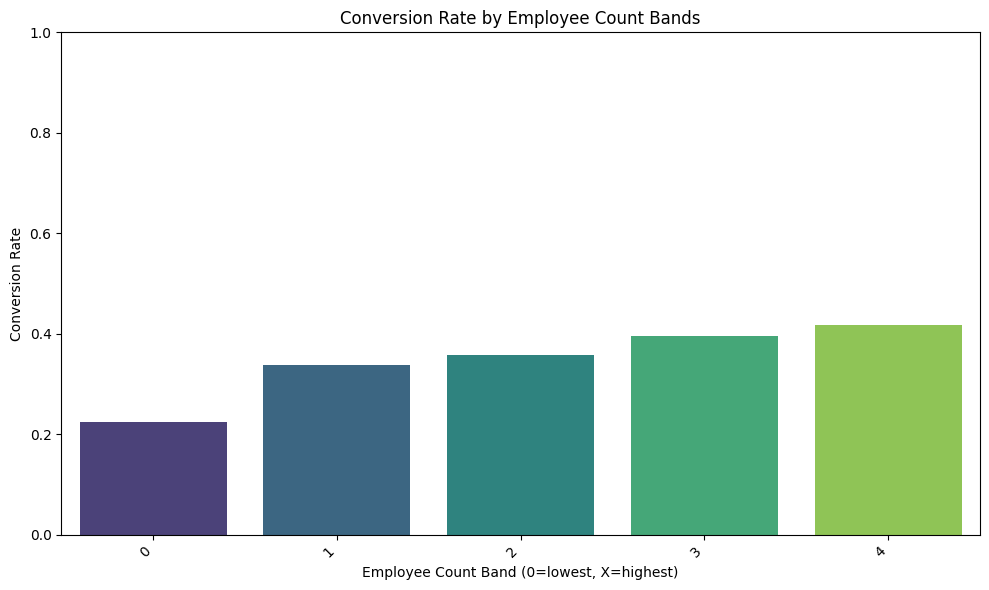

In [ ]:
# Bin the 'TOT_WW_EMPL_NBR' into categories for better visualization
df['Employee_Count_Bands'] = pd.qcut(df['TOT_WW_EMPL_NBR'], q=5, labels=False, duplicates='drop')

conversion_rate_by_employees = df.groupby('Employee_Count_Bands')['conversion_target'].mean().sort_values(ascending=False)
print("Conversion Rate by Employee Count Bands:")
print(conversion_rate_by_employees)

plt.figure(figsize=(10, 6))
sns.barplot(x=conversion_rate_by_employees.index, y=conversion_rate_by_employees.values, palette='viridis')
plt.title('Conversion Rate by Employee Count Bands')
plt.xlabel('Employee Count Band (0=lowest, X=highest)')
plt.ylabel('Conversion Rate')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

Do enrolled agents get more policies?